<a href="https://colab.research.google.com/github/adapasriram/US_HONEY_PRODUCTION/blob/main/bank_additional_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
df = pd.read_csv("/content/bank-additional-full-1.csv",sep=";")

In [8]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


becase in this probelem we need to classify our data into

yes or no means the person will take the subscription or

that why this is binary classification problem

that why we will build a logistic regression model

In [ ]:
#EDA(Exploratory data analysis) -> understand the data / finding the patters in the data
#detecting the null values
# detecting the duplicates
#detecting the outliers

#data preprocessing -> take action to make the data prepared for model building
#handling the null values
#handling with duplicate values
#handling the outliers
#encoding

In [ ]:
#detect the null vlues and handle them

In [9]:
print(df.isnull().sum())

age               4
job               5
marital           5
education         5
default           4
housing           3
loan              4
contact           4
month             3
day_of_week       3
duration          3
campaign          3
pdays             3
previous          3
poutcome          5
emp.var.rate      3
cons.price.idx    4
cons.conf.idx     3
euribor3m         3
nr.employed       3
y                 3
dtype: int64


In [13]:
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

/tmp/ipykernel_3297/3316244767.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mean())


In [15]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_3297/3738049478.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mode()[0])


In [16]:
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [10]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 15


In [11]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

        age          job   marital            education  default housing loan  \
1266   39.0  blue-collar   married             basic.6y       no      no   no   
12261  36.0      retired   married              unknown       no      no   no   
14234  27.0   technician    single  professional.course       no      no   no   
16956  47.0   technician  divorced          high.school       no     yes   no   
18465  32.0   technician    single  professional.course       no     yes   no   
20216  55.0     services   married          high.school  unknown      no   no   
20534  41.0   technician   married  professional.course       no     yes   no   
25217  39.0       admin.   married    university.degree       no      no   no   
28477  24.0     services    single          high.school       no     yes   no   
32516  35.0       admin.   married    university.degree       no     yes   no   
36951  45.0       admin.   married    university.degree       no      no   no   
38281  71.0      retired    

In [12]:
#drop duplicates
df = df.drop_duplicates()

print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


In [ ]:
#detect the outliers and handle them

In [17]:
import numpy as np

# Select numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Detect outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

age: 474 outliers
duration: 2963 outliers
campaign: 2406 outliers
pdays: 1516 outliers
previous: 5633 outliers
emp.var.rate: 0 outliers
cons.price.idx: 0 outliers
cons.conf.idx: 446 outliers
euribor3m: 0 outliers
nr.employed: 0 outliers


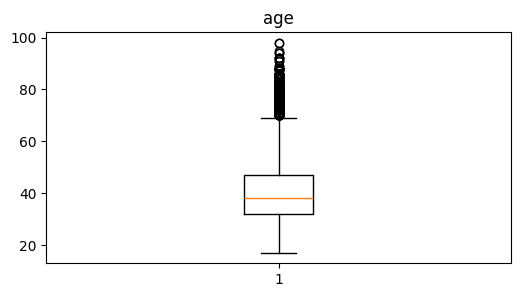

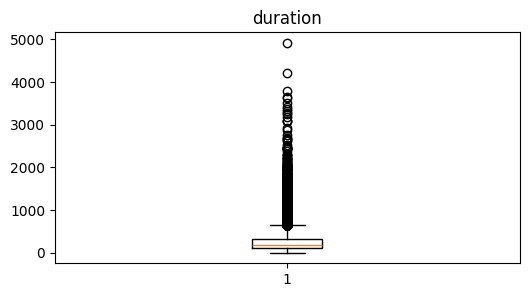

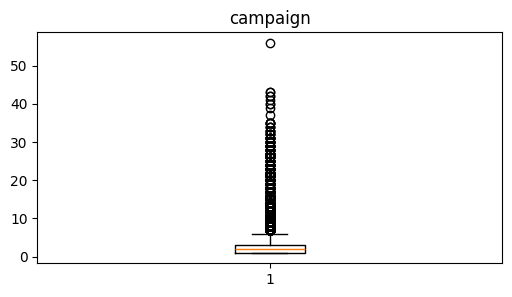

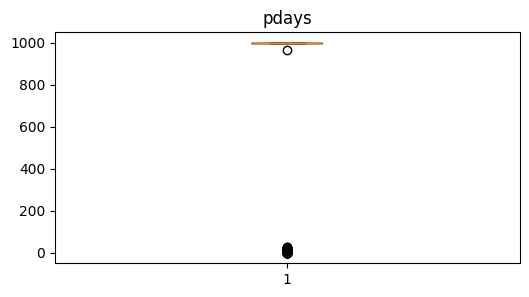

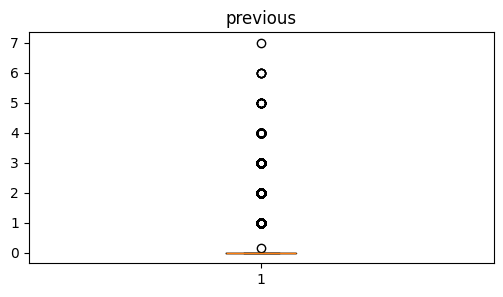

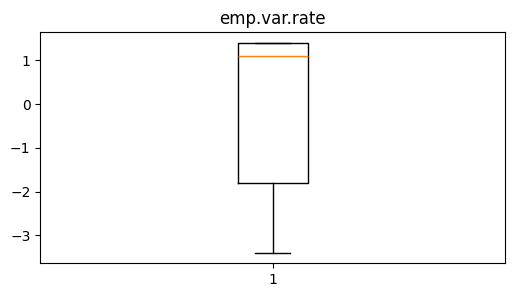

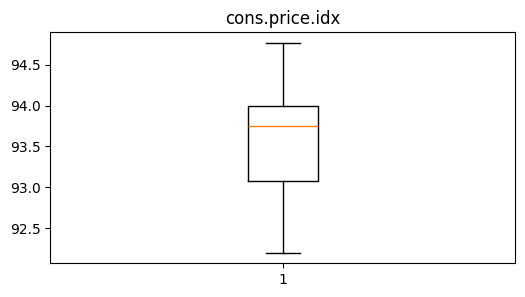

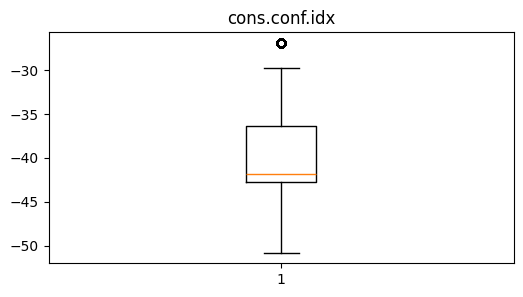

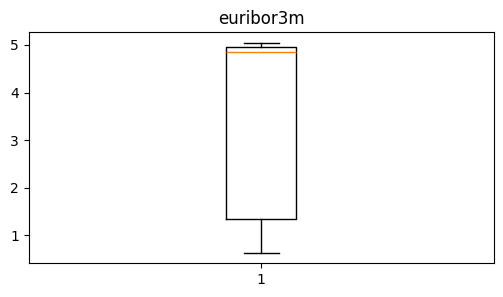

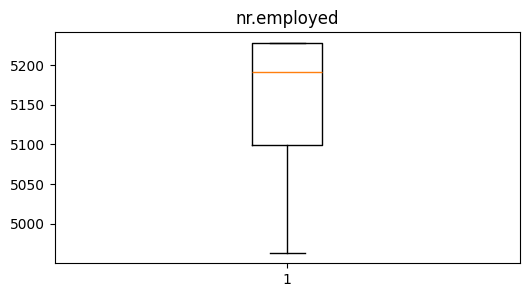

In [20]:
import matplotlib.pyplot as plt

for i in numeric_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [21]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
outliers = ["duraation","campaign","cons.conf.idx",]

In [ ]:
#remove the outliers using iqr method

In [22]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (23098, 21)


In [24]:
#label encode ->
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df)

        age  job  marital  education  default  housing  loan  contact  month  \
0      56.0    3        1          0        0        0     0        1      4   
1      57.0    7        1          3        1        0     0        1      4   
2      37.0    7        1          3        0        2     0        1      4   
3      40.0    0        1          1        0        0     0        1      4   
4      56.0    7        1          3        0        0     2        1      4   
...     ...  ...      ...        ...      ...      ...   ...      ...    ...   
27685  51.0    1        1          0        0        2     2        1      1   
27686  39.0    9        1          5        0        2     0        1      1   
27687  36.0    1        1          3        0        2     0        0      1   
27688  55.0   10        0          5        0        0     0        1      1   
27689  44.0    1        1          0        0        2     2        1      1   

       day_of_week  ...  campaign  pday

In [ ]:
#model Building

In [ ]:
#1. split the data (indpendent(x) and dependent(y))
#2.train test split
#3.train the model
#4.test the model
#5.evaluate the model

In [25]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,4,1,...,1.0,999.0,0.0,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,4,1,...,1.0,999.0,0.0,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,4,1,...,1.0,999.0,0.0,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,4,1,...,1.0,999.0,0.0,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,4,1,...,1.0,999.0,0.0,0,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27685,51.0,1,1,0,0,2,2,1,1,1,...,1.0,999.0,0.0,0,-0.2,92.756,-45.9,3.488,5176.3,0
27686,39.0,9,1,5,0,2,0,1,1,3,...,1.0,999.0,0.0,0,-0.2,92.756,-45.9,3.428,5176.3,0
27687,36.0,1,1,3,0,2,0,0,1,2,...,1.0,999.0,0.0,0,-0.2,92.756,-45.9,3.329,5176.3,0
27688,55.0,10,0,5,0,0,0,1,1,0,...,1.0,999.0,0.0,0,-0.2,92.756,-45.9,3.282,5176.3,0


In [26]:
x = df.drop(columns="y")

In [27]:
y = df["y"]

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
x_train.shape

(18478, 20)

In [32]:
x_test.shape

(4620, 20)

In [ ]:
#3.trai the model --> logistic regression

In [35]:
from sklearn.linear_model import LogisticRegression

In [37]:
model = LogisticRegression()

In [38]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
#test the model

In [39]:
y_pred = model.predict(x_test)

In [ ]:
#evaluation->

In [41]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [43]:
accuracy_score(y_test,y_pred)

0.9805194805194806

In [ ]:
#confusion_matrix

In [44]:
confusion_matrix(y_test,y_pred)

array([[4530,    2],
       [  88,    0]])

In [45]:
(4530+0)/(4530+2+88+0)

0.9805194805194806

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4532
           1       0.00      0.00      0.00        88

    accuracy                           0.98      4620
   macro avg       0.49      0.50      0.50      4620
weighted avg       0.96      0.98      0.97      4620

